In [ ]:
import matplotlib.pyplot as plt
import os

# Números y Datos
import numpy as np

import networkx as nx

from networkx.algorithms.approximation import average_clustering

import community.community_louvain as cl


import pickle



# **1.   Datos**






In [ ]:
!wget -O facebook.txt https://www.dropbox.com/scl/fi/hdgcmyss47w9t676kh2ug/facebook.txt?rlkey=j616y86ejfn6f719jg4b8e413&dl=1
!wget -O email.txt https://www.dropbox.com/scl/fi/w5o34b0olg7xek4s42lml/email-Eu-core.txt?rlkey=g2561imdd4ssyrwfgywrotzwm&st=czqgmef0&dl=1
!wget -O email_labels.txt  https://www.dropbox.com/scl/fi/ij3b6jul7ispiovt18sfm/email-Eu-core-department-labels.txt?rlkey=dqp60qw20pw7biil9cvti4u68&st=zij9wsi8&dl=1

# AHORA ARCHIVOS DE POSICION DE LOS NODOS:
!wget -O email_pos.pkl https://www.dropbox.com/scl/fi/loeuul6gxq7uscd1m7ks8/email_positions.pkl?rlkey=caf194s8198pffo2zaq6767jz&st=kw0c3tu4&dl=1
!wget -O fb_pos.pkl https://www.dropbox.com/scl/fi/ka6v0h9ew5j08haxlbf6b/fb_positions.pkl?rlkey=7ul7jr7re5bziy54cgp3x9tre&st=vp6gjciw&dl=1

--2025-05-02 00:38:17--  https://www.dropbox.com/scl/fi/hdgcmyss47w9t676kh2ug/facebook.txt?rlkey=j616y86ejfn6f719jg4b8e413
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6030:18::a27d:5012
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucf6b9d4b6f301e7bb4515fcfe09.dl.dropboxusercontent.com/cd/0/inline/Co7lLbPLgyCHkhEWiefW06t41aOaL6WeLqTWzRKIgz6pIxSBKXvyNb6vqCH4CxvHmZeVZ0EDD5_Z5jcTshfKMQMJMrWWAhQJJ6HQyO1Itq0zXTDC71Y0lHm7PsjUmZNx7lWTU5BCTCNgi6ww-d2pHwjl/file# [following]
--2025-05-02 00:38:18--  https://ucf6b9d4b6f301e7bb4515fcfe09.dl.dropboxusercontent.com/cd/0/inline/Co7lLbPLgyCHkhEWiefW06t41aOaL6WeLqTWzRKIgz6pIxSBKXvyNb6vqCH4CxvHmZeVZ0EDD5_Z5jcTshfKMQMJMrWWAhQJJ6HQyO1Itq0zXTDC71Y0lHm7PsjUmZNx7lWTU5BCTCNgi6ww-d2pHwjl/file
Resolving ucf6b9d4b6f301e7bb4515fcfe09.dl.dropboxusercontent.com (ucf6b9d4b6f301e7bb4515fcfe09.dl.dropboxusercontent.com)... 162.125.3.15, 2620:

# Funciones útiles

In [ ]:
def read_graph(filename):
    G = nx.Graph()
    array = np.loadtxt(filename, dtype=int)
    G.add_edges_from(array)
    return G


def read_graph_weighted(filename):
    G = nx.Graph()
    array = np.loadtxt(filename, dtype=int)
    G.add_weighted_edges_from(array)
    return G

def read_dir_graph(filename):
    G = nx.DiGraph()
    array = np.loadtxt(filename, dtype=int)
    G.add_edges_from(array)
    return G

def read_dir_graph_weighted(filename):
    G = nx.DiGraph()
    array = np.loadtxt(filename, dtype=int)
    G.add_weighted_edges_from(array)
    return G

def get_graph_pos(filename):
  with open(filename, 'rb') as f:
    posData = pickle.load(f)
  return posData

In [ ]:
fb = read_graph('facebook.txt')
print('Facebook')
print(fb)
print('Es dirigido?:',nx.is_directed(fb))
print('Es pesado?:',nx.is_weighted(fb))
print('Es conectado?:',nx.is_connected(fb))
print('')

Facebook
Graph with 4039 nodes and 88234 edges
Es dirigido?: False
Es pesado?: False
Es conectado?: True



In [ ]:
email = read_graph('email.txt')
print('Email')
print(email)
print('Es dirigido?:',nx.is_directed(email))
print('Es pesado?:',nx.is_weighted(email))
print('Es conectado?:',nx.is_connected(email))
print('')

Email
Graph with 1005 nodes and 16706 edges
Es dirigido?: False
Es pesado?: False
Es conectado?: False



¿Cuál es la componente gigante del grafo Email?

In [ ]:
G=email
G.remove_edges_from(nx.selfloop_edges(G)) # Borro autoenlaces
Gcc = sorted(nx.connected_components(G), key=len, reverse=True)
emailGiant = G.subgraph(Gcc[0])
print(emailGiant)
print('Es dirigido?:',nx.is_directed(emailGiant))
print('Es pesado?:',nx.is_weighted(emailGiant))
print('Es conectado?:',nx.is_connected(emailGiant))
print('')

Graph with 986 nodes and 16064 edges
Es dirigido?: False
Es pesado?: False
Es conectado?: True



In [ ]:
def sample_path_lengths(G, nodes=None, trials=1000):
    if nodes is None:
        nodes = list(G)
    else:
        nodes = list(nodes)

    pairs = np.random.choice(nodes, (trials, 2))
    lengths = [nx.shortest_path_length(G, *pair)
               for pair in pairs]
    return lengths

def estimate_path_length(G, nodes=None, trials=1000):
    return np.mean(sample_path_lengths(G, nodes, trials))

In [ ]:
print('Camino mínimo FB')
## DISTANCIAS

print(estimate_path_length(fb))
print('')

print('coeficiente de clustering medio FB')
## COEFICIENTE DE CLUSTERING

print(average_clustering(fb, trials=1000))


print('caminos mínimos medios componente gigante Email')

# ESTO DEMORA MENOS DE 1 SEGUNDO
print(estimate_path_length(emailGiant))
print('')

print('coeficiente de clustering medio Email')
## COEFICIENTE DE CLUSTERING
print(average_clustering(emailGiant, trials=1000))

Camino mínimo FB
3.647

coeficiente de clustering medio FB
0.626
caminos mínimos medios componente gigante Email
2.585

coeficiente de clustering medio Email
0.399


In [ ]:
pos_email=get_graph_pos('email_pos.pkl')


In [ ]:
pos_fb=get_graph_pos('fb_pos.pkl')

Centralidad

In [ ]:
def plotNodeAttribute(G, pos, attribute, exaggeration):
    # SOLO NODOS QUE EXISTEN EN POS
    nodes_with_pos = set(pos.keys())
    nodes_to_draw = [n for n in G.nodes if n in nodes_with_pos]

    # Valores de atributo SOLO para los nodos que tienen posición
    values = [attribute[n] for n in nodes_to_draw]

    # Escalado del tamaño de nodos
    nsize = np.array(values)
    nsize = exaggeration * (nsize - min(nsize)) / (max(nsize) - min(nsize))

    # Dibujamos sólo los nodos correctos
    nx.draw(
        G.subgraph(nodes_to_draw),
        pos=pos,
        node_size=nsize,
        alpha=0.4,
        node_color=values,
        edge_color='orange',
        width=0.1
    )


Centralidad FB


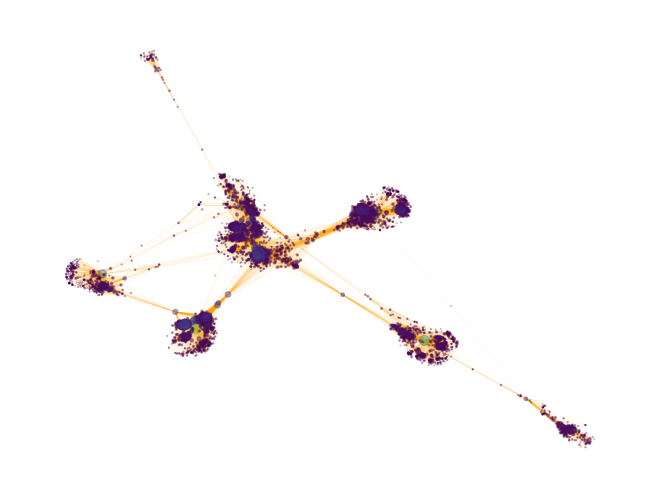

In [ ]:
print('Centralidad FB')
centrality = nx.degree_centrality(fb)
exaggeration=100
plotNodeAttribute(fb,pos_fb,centrality,exaggeration)

Centralidad de Grado de Email


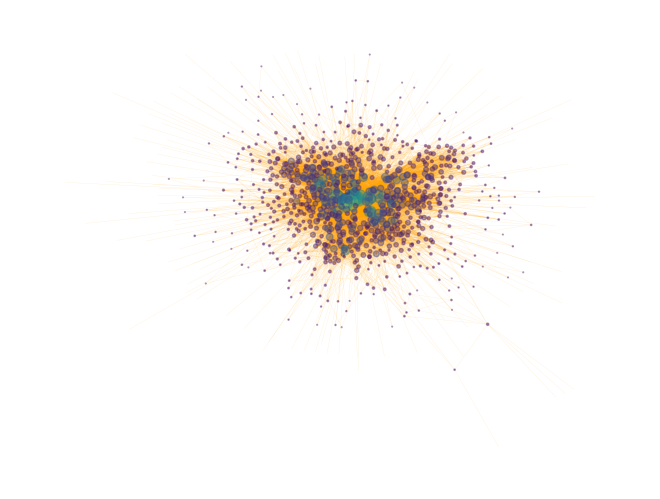

In [ ]:
print('Centralidad de Grado de Email')
centrality = nx.degree_centrality(emailGiant)
exaggeration=100

#nx.draw(G, layout, node_size=25, edge_color='green', node_color=n_color, width=0.2, vmin=vmin, vmax=vmax,cmap=cmap)
plotNodeAttribute(emailGiant,pos_email,centrality,exaggeration)

In [ ]:
#betweenness_fb = nx.betweenness_centrality(fb, normalized=True)

# Calcular betweenness centrality para Email
#betweenness_email = nx.betweenness_centrality(email, normalized=True)

In [ ]:
#plotNodeAttribute(emailGiant,pos_email,betweenness_email,exaggeration)

NameError: name 'betweenness_email' is not defined

**INTERPRETACION**

nx.degree_centrality(G) asigna a cada nodo un valor entre 0 y 1, que representa:

La cantidad de conexiones directas que tiene un nodo, normalizada por el total de nodos posibles.

Es una medida local de importancia:
Cuantos más vecinos tenga un nodo, mayor su centralidad.

**Red de Facebook **
Varias comunidades densas con nodos internos bien conectados.

Nodos más grandes y más verdes (alta centralidad) están: Dentro de comunidades → probablemente los miembros más populares. O en nodos-puente que conectan comunidades.


En la red de Facebook, la centralidad de grado resalta nodos altamente conectados dentro de comunidades locales, indicando una estructura modular con hubs comunitarios. No hay un único centro dominante, sino varios "centros locales".


**Red de Emails**
Un núcleo denso con muchos nodos de alta centralidad de grado.

Muchos nodos periféricos con grado bajo.

En la red de Emails, la centralidad de grado muestra una estructura centralizada, con un conjunto reducido de nodos que concentran la mayoría de las conexiones. Esto refleja un patrón típico en redes organizacionales, donde ciertos individuos (como administradores o coordinadores) canalizan la comunicación.

In [ ]:
import community.community_louvain as community_louvain
# 1. Detectar partición de comunidades
partition = community_louvain.best_partition(fb)

# `partition` es un diccionario: nodo → número de comunidad
print(f"Ejemplo de partición: {list(partition.items())[:10]}")


Ejemplo de partición: [(np.int64(0), 0), (np.int64(1), 0), (np.int64(2), 0), (np.int64(3), 0), (np.int64(4), 0), (np.int64(5), 0), (np.int64(6), 0), (np.int64(7), 0), (np.int64(8), 0), (np.int64(9), 0)]


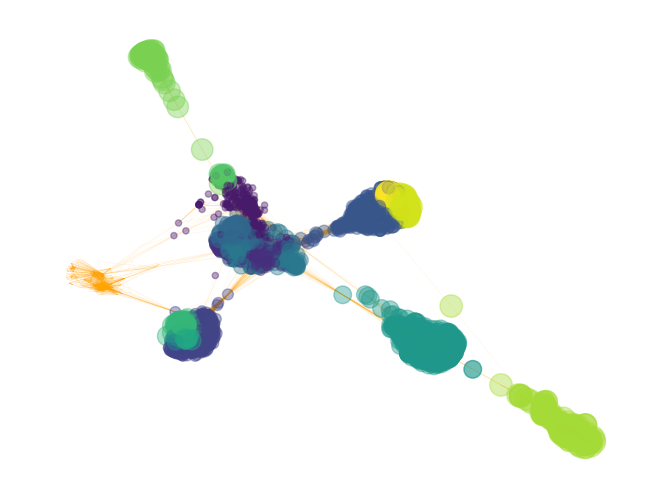

In [ ]:
plotNodeAttribute(fb, pos_fb, partition, exaggeration=300)

In [ ]:
# 1. Detectar partición de comunidades
partition = community_louvain.best_partition(email)

# `partition` es un diccionario: nodo → número de comunidad
print(f"Ejemplo de partición: {list(partition.items())[:10]}")

Ejemplo de partición: [(np.int64(0), 0), (np.int64(1), 0), (np.int64(2), 12), (np.int64(3), 12), (np.int64(4), 12), (np.int64(5), 12), (np.int64(6), 12), (np.int64(7), 2), (np.int64(8), 2), (np.int64(9), 2)]


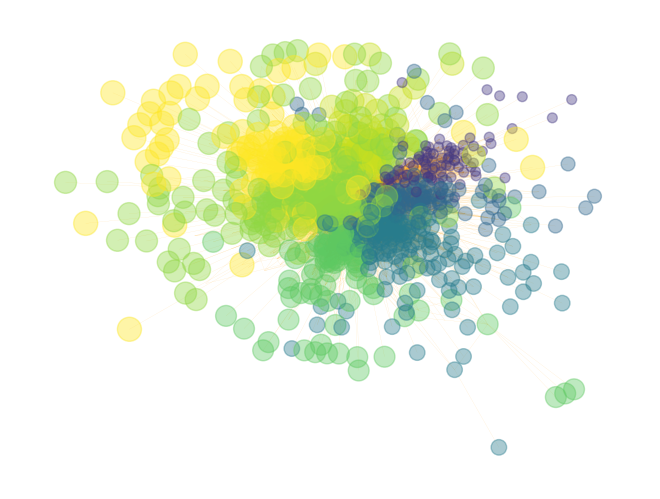

In [ ]:
plotNodeAttribute(email, pos_email, partition, exaggeration=300)

La modularidad es una medida que te dice qué tan buena es una partición de comunidades:

Cuanto más alto el valor (máximo 1), mejor la estructura modular (más conexiones dentro de comunidades, menos entre ellas).

En la práctica, valores > 0.3 ya indican comunidades significativas.



**INTERPRETACION**

**Red de Facebook**
Se forman grupos claramente diferenciados (bien separados espacialmente).

Cada comunidad es compacta, con pocos puentes entre ellas.

Hay una comunidad central que actúa como nexo entre varias otras.

El algoritmo de Louvain identifica comunidades muy definidas en la red de Facebook, reflejando agrupamientos sociales (como círculos de amigos). La red tiene una estructura modular natural, lo que sugiere que los enlaces dentro de los grupos son significativamente más frecuentes que entre grupos.
Esto es esperable en redes sociales, donde los vínculos tienden a reforzarse entre personas que comparten contexto o intereses.

**Red de Emails**

A pesar del alto grado de conectividad del núcleo, el algoritmo logra separar múltiples comunidades.

Los colores se intercalan más que en Facebook: las comunidades están más entrelazadas.

Hay nodos periféricos que se agrupan por comunidad, pero el centro tiene zonas de superposición.


Interpretación:
En la red de Emails, el algoritmo Louvain identifica comunidades, pero con menos separación visual clara que en Facebook. Esto es coherente con un entorno organizacional: aunque las personas pertenezcan a distintos departamentos, existen conexiones funcionales cruzadas (mails entre departamentos, jefaturas, administración).
La modularidad probablemente sea más baja que en Facebook, indicando que las comunidades no están tan marcadas.

In [ ]:
partition = community_louvain.best_partition(emailGiant)
mod = community_louvain.modularity(partition, emailGiant)
print(f"Modularidad de la partición: {mod:.4f}")



Modularidad de la partición: 0.4143


In [ ]:
partition = community_louvain.best_partition(fb)
mod = community_louvain.modularity(partition, fb)
print(f"Modularidad de la partición: {mod:.4f}")

Modularidad de la partición: 0.8349


Interpretación
~0.0 No hay estructura de comunidad

0.3 - 0.5 Comunidades presentes pero no muy marcadas

0.5 - 0.7+ Comunidades bien definidas

0.8+ Sospechoso: puede ser sobreajuste (overfitting)

 gráfico donde:

El tamaño de cada nodo represente su grado (más conexiones → más grande),

El color de cada nodo represente su coeficiente de clustering local (qué tan conectados están sus vecinos).

Esto te permite ver:

Qué nodos son hubs (muy conectados),

Y si esos hubs están en regiones densamente conectadas o no.


Nodos más grandes → tienen más conexiones.

Nodos más claros/amarillos → tienen vecinos muy interconectados (alto clustering).

Nodos más oscuros/azules → están más aislados o dispersos.

# **gráfico donde los nodos de la red de Emails estén coloreados por departamento real (usando email_labels.txt), para que se pueda:**

Visualizar las divisiones reales (como departamentos),

Y compararlas con las comunidades detectadas por Louvain (que ya están graficadas).

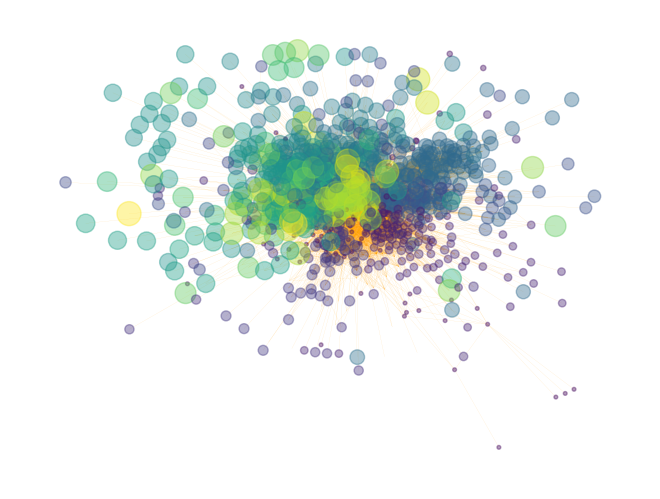

In [ ]:
# Las etiquetas reales
email_labels = {}
with open('email_labels.txt', 'r') as f:
    for line in f:
        node, label = line.strip().split()
        email_labels[int(node)] = int(label)


plotNodeAttribute(email, pos_email, email_labels, exaggeration=300)

In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# Filtrar nodos que existan en ambos (por si hay diferencias)
nodos_validos = set(partition.keys()) & set(email_labels.keys())

# Crear listas alineadas
predicted = [partition[n] for n in nodos_validos]
real = [email_labels[n] for n in nodos_validos]

# Calcular métricas
nmi = normalized_mutual_info_score(real, predicted)
ari = adjusted_rand_score(real, predicted)

print(f"NMI (Normalized Mutual Information): {nmi:.4f}")
print(f"ARI (Adjusted Rand Index): {ari:.4f}")


NMI (Normalized Mutual Information): 0.0735
ARI (Adjusted Rand Index): 0.0065


¿Cómo interpretar los valores?

Valor de NMI / ARI	Interpretación
~0.0	Ninguna coincidencia real
0.3 – 0.5	Coincidencia parcial (moderada)
> 0.5	Buena coincidencia
1.0	Coincidencia perfecta

<ipython-input-24-a1deaf0213a7>:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = cm.get_cmap(cmap, len(comunidades))


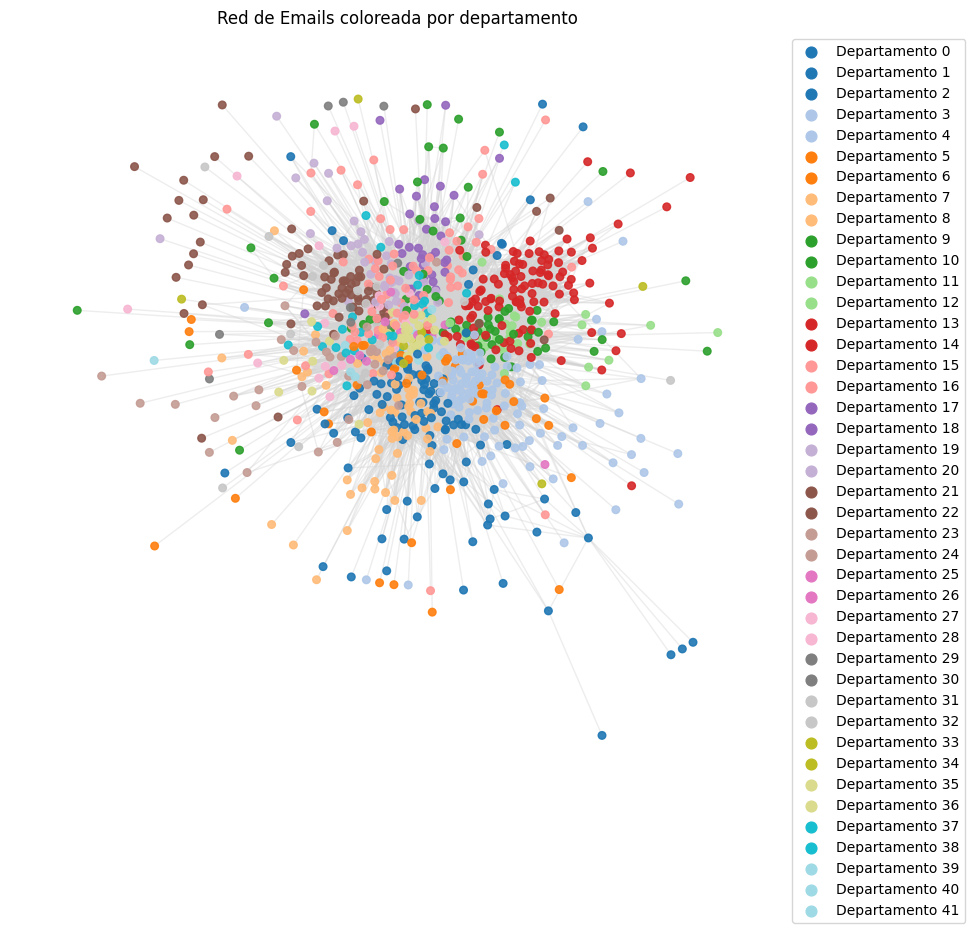

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

def plot_departamentos_con_leyenda(G, pos, labels_dict, title="Departamentos reales", cmap='tab20'):
    # Filtrar nodos con posición
    nodes_with_pos = set(pos.keys())
    nodos_validos = [n for n in G.nodes if n in nodes_with_pos and n in labels_dict]

    # Obtener comunidades únicas
    comunidades = sorted(set(labels_dict[n] for n in nodos_validos))
    colores = cm.get_cmap(cmap, len(comunidades))

    # Asignar un color por comunidad
    comunidad_a_color = {com: colores(i) for i, com in enumerate(comunidades)}
    colores_nodos = [comunidad_a_color[labels_dict[n]] for n in nodos_validos]

    # Dibujar
    plt.figure(figsize=(10, 10))
    nx.draw_networkx_nodes(
        G.subgraph(nodos_validos),
        pos=pos,
        node_size=30,
        node_color=colores_nodos,
        alpha=0.9
    )
    nx.draw_networkx_edges(
        G.subgraph(nodos_validos),
        pos=pos,
        edge_color='lightgray',
        alpha=0.4
    )

    # Crear leyenda
    for com in comunidades:
        plt.scatter([], [], c=[comunidad_a_color[com]], label=f'Departamento {com}', s=60)
    plt.legend(loc='best', bbox_to_anchor=(1, 1))

    plt.title(title)
    plt.axis('off')
    plt.show()

# Usar la función
plot_departamentos_con_leyenda(email, pos_email, email_labels, title="Red de Emails coloreada por departamento")


<ipython-input-25-82f497dc4eb3>:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = cm.get_cmap(cmap, len(comunidades))


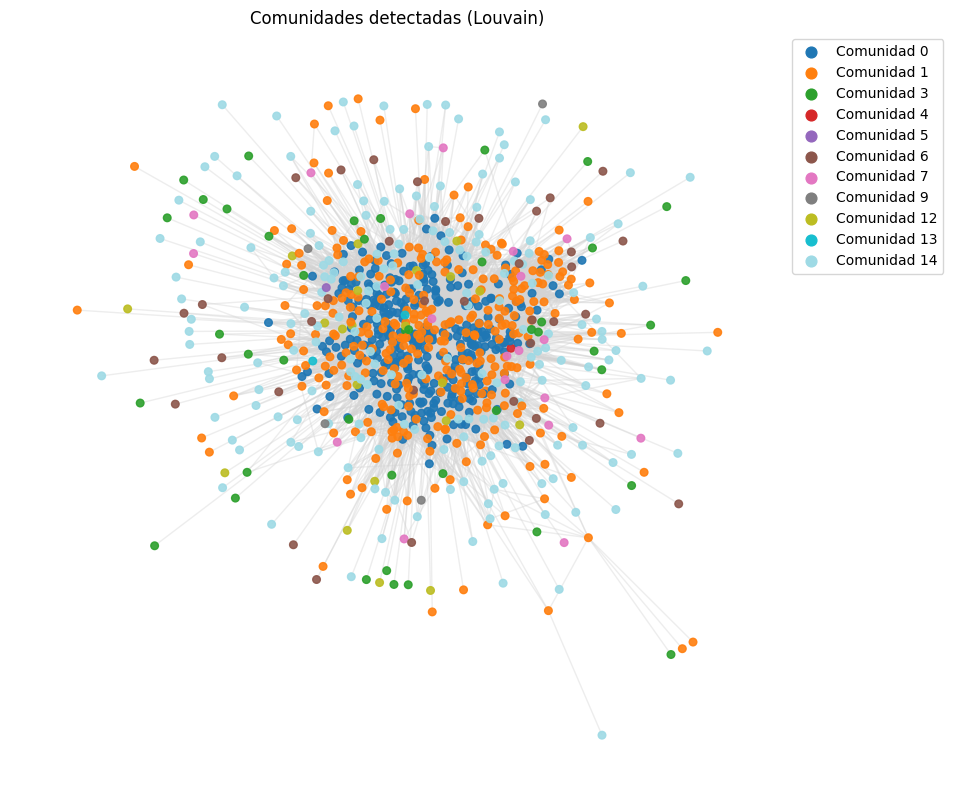

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx

def plot_comunidades_con_leyenda(G, pos, partition_dict, title="Comunidades detectadas (Louvain)", cmap='tab20'):
    # Filtrar nodos válidos
    nodes_with_pos = set(pos.keys())
    nodos_validos = [n for n in G.nodes if n in nodes_with_pos and n in partition_dict]

    # Comunidades únicas
    comunidades = sorted(set(partition_dict[n] for n in nodos_validos))
    colores = cm.get_cmap(cmap, len(comunidades))

    # Asignar color a cada comunidad
    comunidad_a_color = {com: colores(i) for i, com in enumerate(comunidades)}
    colores_nodos = [comunidad_a_color[partition_dict[n]] for n in nodos_validos]

    # Dibujar
    plt.figure(figsize=(10, 10))
    nx.draw_networkx_nodes(
        G.subgraph(nodos_validos),
        pos=pos,
        node_size=30,
        node_color=colores_nodos,
        alpha=0.9
    )
    nx.draw_networkx_edges(
        G.subgraph(nodos_validos),
        pos=pos,
        edge_color='lightgray',
        alpha=0.4
    )

    # Crear leyenda
    for com in comunidades:
        plt.scatter([], [], c=[comunidad_a_color[com]], label=f'Comunidad {com}', s=60)
    plt.legend(loc='best', bbox_to_anchor=(1, 1))

    plt.title(title)
    plt.axis('off')
    plt.show()


plot_comunidades_con_leyenda(email, pos_email, partition)

Interpretación:

Para evaluar el grado en que las comunidades detectadas reflejan divisiones funcionales reales, se comparó la partición generada por el algoritmo de Louvain con los departamentos a los que pertenece cada nodo en la red de Emails.
El resultado arrojó una Normalized Mutual Information (NMI) de 0.0735 y un Adjusted Rand Index (ARI) de 0.0065, lo que indica una muy baja correspondencia entre ambas particiones.
Visualmente, también se observa una gran dispersión de nodos de un mismo departamento, lo que sugiere que la estructura organizacional formal no se refleja directamente en la topología de enlaces de la red.
Esto podría deberse a que los correos electrónicos cruzan departamentos con frecuencia, reflejando patrones de comunicación funcional más que jerarquías estructurales.




La estructura de comunidades detectadas mediante el algoritmo de Louvain no coincide significativamente con la partición por departamentos reales. Esto se refleja tanto numéricamente (bajos valores de NMI y ARI) como visualmente, donde los colores se distribuyen de forma diferente en ambas representaciones.
Este resultado sugiere que las comunidades estructurales emergentes de la red de emails no reflejan necesariamente las divisiones administrativas, sino que podrían responder a patrones funcionales o colaborativos transversales a los departamentos.

In [ ]:
def plotNodeAttributeDual(G, pos, size_attr, color_attr, size_exaggeration=300, cmap='viridis'):
    import numpy as np
    import matplotlib.pyplot as plt

    # Solo nodos con posición
    nodes_with_pos = set(pos.keys())
    nodes_to_draw = [n for n in G.nodes if n in nodes_with_pos]

    # Atributos filtrados
    sizes = np.array([size_attr[n] for n in nodes_to_draw])
    colors = np.array([color_attr[n] for n in nodes_to_draw])

    # Escalar tamaños
    sizes_scaled = size_exaggeration * (sizes - sizes.min()) / (sizes.max() - sizes.min() + 1e-8)

    # Dibujar
    fig, ax = plt.subplots(figsize=(10, 10)) # Create a figure and an axes object
    nx.draw(
        G.subgraph(nodes_to_draw),
        pos=pos,
        node_size=sizes_scaled,
        node_color=colors,
        edge_color='lightgray',
        cmap=plt.get_cmap(cmap),
        alpha=0.8,
        with_labels=False,
        ax=ax # Pass the axes object to nx.draw
    )
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=colors.min(), vmax=colors.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Clustering coefficient') # Specify the axes for the colorbar
    plt.title('Tamaño = Grado / Color = Clustering')
    plt.axis('off')
    plt.show()


In [ ]:
# Grado (para tamaño)
degree_dict = dict(email.degree())

# Clustering (para color)
clustering_dict = nx.clustering(email)


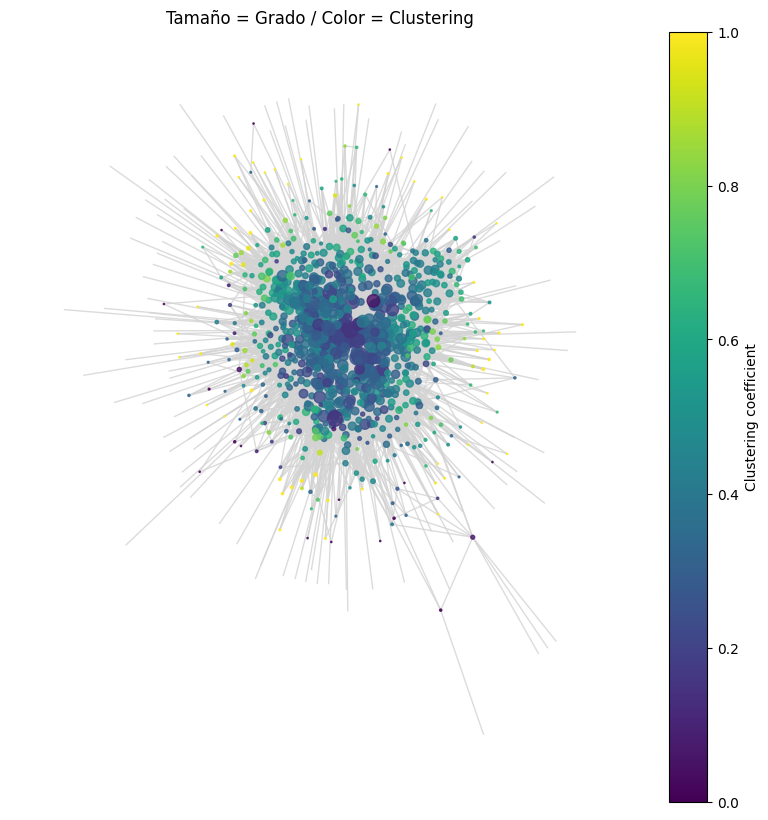

In [ ]:
plotNodeAttributeDual(email, pos_email,
    size_attr=degree_dict,          # tamaño según grado
    color_attr=clustering_dict,     # color según clustering
    size_exaggeration=300
)


In [ ]:
# Grado (para tamaño)
degree_dict = dict(fb.degree())

# Clustering (para color)
clustering_dict = nx.clustering(fb)

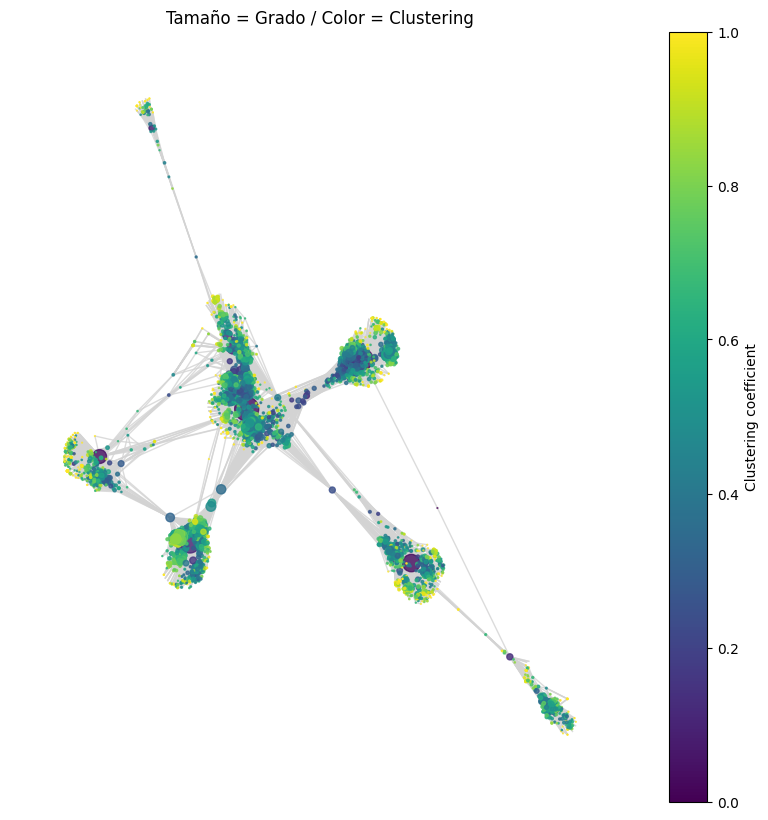

In [ ]:
plotNodeAttributeDual(fb, pos_fb,
    size_attr=degree_dict,          # tamaño según grado
    color_attr=clustering_dict,     # color según clustering
    size_exaggeration=300
)

**INTERPRETACION**

** Red de Emails**

Nodos grandes en el centro → individuos con muchos contactos (alta centralidad de grado).

Color azul-verde (clustering bajo a medio) → esos nodos centrales tienen vecinos poco conectados entre sí.

Colores amarillos más en la periferia → nodos con pocos contactos, pero cuyos vecinos forman grupos cerrados.


La red de emails tiene una estructura centralizada: unos pocos individuos concentran muchas conexiones, pero sus contactos están poco interconectados (bajo clustering). Esto es típico de estructuras organizacionales jerárquicas, donde personas clave (administrativos, coordinación) interactúan con muchos otros que no necesariamente se conectan entre sí.

**Red de Facebook**

Grupos bien definidos, compactos, con nodos grandes y amarillos.

Alta densidad de color amarillo/verde → alto clustering (mucha interconexión entre vecinos).

Pocos nodos grandes con clustering bajo: puentes entre comunidades.


La red de Facebook muestra una estructura modular y descentralizada. Los nodos con más conexiones están inmersos en grupos densos, donde sus contactos también están conectados entre sí (alto clustering). Esto es característico de redes sociales reales, donde los grupos suelen estar formados por círculos de amistad muy interconectados.


Conclusión
La comparación entre ambas redes revela estructuras funcionales distintas: la red de Facebook presenta una estructura comunitaria con alto grado de clustering local, donde las conexiones se concentran dentro de grupos altamente cohesivos. En cambio, la red de Emails exhibe un patrón centralizado con bajo clustering en los nodos más conectados, lo cual sugiere un flujo de información más jerárquico y radial. Estas diferencias reflejan las dinámicas sociales propias de cada red: colaborativas en Facebook, funcionales y organizacionales en el entorno de Emails.

Clustering promedio
Mide cuán interconectados están los vecinos de los nodos, en promedio:

\langle C \rangle = \frac{1}{N} \sum_i C_i

Grado promedio
Mide cuántas conexiones directas tiene un nodo en promedio:

\langle k \rangle = \frac{2L}{N} ]



Mayor grado promedio → Red más densamente conectada.

Mayor clustering promedio → Red con mayor cohesión local (grupos cerrados, triángulos).

In [ ]:
def resumen_topologico(G, nombre):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    avg_degree = sum(dict(G.degree()).values()) / n
    avg_clustering = nx.average_clustering(G)

    print(f"Resumen de la red: {nombre}")
    print(f"  Nodos: {n}")
    print(f"  Enlaces: {m}")
    print(f"  Grado promedio: {avg_degree:.2f}")
    print(f"  Clustering promedio: {avg_clustering:.4f}")
    print("-" * 40)

# Aplica a ambas redes
resumen_topologico(fb, "Facebook")
resumen_topologico(email, "Emails")


Resumen de la red: Facebook
  Nodos: 4039
  Enlaces: 88234
  Grado promedio: 43.69
  Clustering promedio: 0.6055
----------------------------------------
Resumen de la red: Emails
  Nodos: 1005
  Enlaces: 16064
  Grado promedio: 31.97
  Clustering promedio: 0.3994
----------------------------------------


El análisis topológico revela diferencias significativas entre ambas redes.
La red de Facebook presenta un grado promedio más alto (⟨𝑘⟩ = 43.69 y un clustering promedio considerablemente mayor ( ⟨𝐶⟩ = 0.6055, lo cual indica una estructura altamente densa y modular, característica de redes sociales con círculos de amistad interconectados.

En contraste, la red de Emails, con un grado promedio menor ( ⟨𝑘⟩ = 31.97) y clustering promedio también más bajo ( ⟨𝐶⟩ = 0.3994), muestra una topología menos cohesiva, donde los nodos tienden a conectarse con nodos centrales sin formar triángulos locales.
Esta diferencia sugiere que la red de Emails sigue un patrón más jerárquico y funcional, mientras que Facebook presenta una organización más comunitaria y descentralizada.

Vamos a comparar las redes reales (Facebook y Emails) con modelos clásicos de redes para entender si tienen propiedades similares a redes:

Erdős–Rényi (ER) – Red aleatoria pura

Barabási–Albert (BA) – Red scale-free (libre de escala)

Watts - Strogatz (WS) - Red small world (mundo pequeño)


¿Mi red tiene propiedades esperadas en una red aleatoria o muestra estructura especial?


Para cada modelo, vamos a generar una red con el mismo número de nodos y enlaces (o lo más aproximado posible), y luego comparar:

Grado promedio

Clustering promedio

Distancia promedio (opcional)

In [ ]:
import networkx as nx

def comparar_modelos(G_real, nombre, n, m):
    print(f"\n=== Comparación para {nombre} ===")

    # Modelo Erdős–Rényi
    p = (2 * m) / (n * (n - 1))  # Probabilidad esperada de conexión
    G_er = nx.erdos_renyi_graph(n, p)

    # Modelo Barabási–Albert
    m_ba = m // n  # enlaces por nuevo nodo
    G_ba = nx.barabasi_albert_graph(n, m_ba)

    # Modelo Watts–Strogatz
    k_ws = 2 * (m // n)
    G_ws = nx.watts_strogatz_graph(n, k_ws, p=0.1)

    # Clustering y grado
    for modelo, G_sim in [("Erdős–Rényi", G_er), ("Barabási–Albert", G_ba),  ("Watts–Strogatz", G_ws)]:
        grado = sum(dict(G_sim.degree()).values()) / G_sim.number_of_nodes()
        clustering = nx.average_clustering(G_sim)
        print(f"{modelo}:")
        print(f"  Grado promedio: {grado:.2f}")
        print(f"  Clustering promedio: {clustering:.4f}")

# Facebook
comparar_modelos(fb, "Facebook", n=4039, m=88234)

# Emails
comparar_modelos(email, "Emails", n=1005, m=16064)



=== Comparación para Facebook ===
Erdős–Rényi:
  Grado promedio: 43.87
  Clustering promedio: 0.0108
Barabási–Albert:
  Grado promedio: 41.78
  Clustering promedio: 0.0368
Watts–Strogatz:
  Grado promedio: 42.00
  Clustering promedio: 0.5361

=== Comparación para Emails ===
Erdős–Rényi:
  Grado promedio: 32.17
  Clustering promedio: 0.0320
Barabási–Albert:
  Grado promedio: 29.55
  Clustering promedio: 0.0790
Watts–Strogatz:
  Grado promedio: 30.00
  Clustering promedio: 0.5401


In [ ]:
def calcular_distancia_media(G):
    if nx.is_connected(G):
        return nx.average_shortest_path_length(G)
    else:
        # Trabajamos con la componente gigante si no está conectado
        G_gc = max(nx.connected_components(G), key=len)
        G_sub = G.sim.subgraph(G_gc)
        return nx.average_shortest_path_length(G_sub)

# Parámetros de las redes reales
n_fb, m_fb = 4039, 88234
n_em, m_em = 1005, 16064

# Modelos para Facebook
p_fb = (2 * m_fb) / (n_fb * (n_fb - 1))
G_er_fb = nx.erdos_renyi_graph(n_fb, p_fb)
G_ba_fb = nx.barabasi_albert_graph(n_fb, m_fb // n_fb)
G_ws_fb = nx.watts_strogatz_graph(n_fb, 2 * (m_fb // n_fb), p=0.1)

# Modelos para Emails
p_em = (2 * m_em) / (n_em * (n_em - 1))
G_er_em = nx.erdos_renyi_graph(n_em, p_em)
G_ba_em = nx.barabasi_albert_graph(n_em, m_em // n_em)
G_ws_em = nx.watts_strogatz_graph(n_em, 2 * (m_em // n_em), p=0.1)

# Calculamos las distancias
distancias = {}

distancias["Facebook - Erdős–Rényi"] = calcular_distancia_media(G_er_fb)
distancias["Emails - Erdős–Rényi"] = calcular_distancia_media(G_er_em)

distancias["Facebook - Barabási–Albert"] = calcular_distancia_media(G_ba_fb)
distancias["Emails - Barabási–Albert"] = calcular_distancia_media(G_ba_em)

distancias["Facebook - Watts–Strogatz"] = calcular_distancia_media(G_ws_fb)
distancias["Emails - Watts–Strogatz"] = calcular_distancia_media(G_ws_em)

# Mostrar resultados
print("\n=== Comparación de distancias mínimas promedio ===")
for clave, valor in distancias.items():
    print(f"{clave}: {valor:.4f}")


=== Comparación de distancias mínimas promedio ===
Facebook - Erdős–Rényi: 2.6063
Emails - Erdős–Rényi: 2.3216
Facebook - Barabási–Albert: 2.5357
Emails - Barabási–Albert: 2.3339
Facebook - Watts–Strogatz: 3.0031
Emails - Watts–Strogatz: 2.8003


Comparación (Red real vs modelos)


Facebook

Métrica	Red         Real	ER Model	BA Model
Grado promedio	    43.69	43.77	41.78
Clustering promedio	0.6055	0.0108	0.0368


Conclusión:

El grado promedio es similar en todos los casos (como esperábamos).

Pero el clustering en la red real es mucho más alto.

Red ER predice un clustering casi nulo.

Red BA también subestima fuertemente el clustering.

Esto sugiere que Facebook es una red small-world (corta distancia media y alto clustering), no bien representada por ER ni BA.


Emails

Métrica	Red           Real	ER Model	BA Model
Grado promedio	      31.97	31.71	29.55
Clustering promedio	  0.3994	0.0317	0.0799

Conclusión:

Nuevamente, el grado promedio está bien ajustado.

El clustering real es muy superior al predicho por ER o BA.

La red de Emails también muestra estructura no aleatoria:
tiene grupos o patrones funcionales que ni el modelo aleatorio (ER) ni el modelo de crecimiento con preferencia (BA) explican.

Al comparar ambas redes con **modelos teóricos (Erdős–Rényi y Barabási–Albert)**, se observa que aunque el grado promedio está correctamente ajustado, el clustering promedio en las redes reales es sustancialmente mayor.
En Facebook (⟨C⟩=0.6055), los modelos predicen valores inferiores a 0.04, y en Emails (⟨C⟩=0.3994) sucede lo mismo.
Esto indica que ambas redes poseen una estructura de tipo small-world, donde los nodos forman comunidades densamente conectadas, muy alejadas de lo que se esperaría en redes aleatorias o solo basadas en crecimiento preferencial.
Por tanto, la complejidad de estas redes no puede ser explicada únicamente por modelos simples como ER o BA, lo que justifica el uso de análisis más avanzados como detección de comunidades o métricas de centralidad.
**Comparar con Wattz- Strogatz**: El modelo Watts–Strogatz reproduce razonablemente bien el grado promedio de la red de Facebook. Además, su alto clustering refleja adecuadamente una de las características clave de redes sociales reales: la tendencia a formar triángulos (amigos de mis amigos suelen ser amigos entre sí). Por lo tanto, es un buen modelo para captar la estructura local de la red de Facebook. El modelo WS ajusta bien el grado promedio de la red de Emails, y genera un clustering muy alto, lo cual puede no coincidir totalmente con la realidad si la red de Emails tuviera modularidad por departamentos pero bajo clustering local. En este caso, el modelo puede sobreestimar la cohesión local si la estructura real es más jerárquica o segmentada.

**== Comparación de distancias mínimas promedio ==**
La red de Emails presenta distancias mínimas promedio más bajas que la red de Facebook en todos los modelos comparados, sugiriendo una estructura potencialmente más eficiente para el flujo de información en términos de topología. El modelo de Barabási–Albert es el que mejor optimiza las rutas cortas, mientras que el de Watts–Strogatz prioriza clustering a costa de rutas más largas.(Del dataset de Email se usó la componente gigante)
